# Cerința 5 — UDF și Optimizarea Hiperparametrilor

Această cerință demonstrează două tehnici în Spark: **UDF** (funcție Python personalizată, înregistrată și în Spark SQL) și **optimizarea hiperparametrilor** cu `CrossValidator` + `ParamGridBuilder` (validare încrucișată k-fold).


In [1]:
import os
# Notebook-urile stau în subfolderul notebooks/; ne asigurăm că lucrăm din rădăcina proiectului
# (unde se află data/, models/, plots/), astfel încât toate căile relative să funcționeze.
if not os.path.isdir('data') and os.path.isdir(os.path.join('..', 'data')):
    os.chdir('..')
# Directoarele de output trebuie să existe înainte de orice savefig()/save()
os.makedirs('plots', exist_ok=True)
os.makedirs('models', exist_ok=True)
print('Working directory:', os.getcwd())

Working directory: /Users/stefan/Documents/football-events-analysis


In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, udf, pandas_udf
from pyspark.sql.types import FloatType, StringType
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (11, 5)
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

spark = SparkSession.builder \
    .appName('FootballUDF_HyperTuning') \
    .config('spark.driver.memory', '4g') \
    .config('spark.sql.shuffle.partitions', '8') \
    .getOrCreate()
spark.sparkContext.setLogLevel('ERROR')
print('Spark version:', spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/11 20:07:16 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.1.2


### Citirea datelor procesate — dependență de Cerința 4

Citim Parquet-ul `data/processed_shots` scris de pipeline-ul ETL din Cerința 4 (cu fallback pe CSV brut dacă lipsește). Refolosirea artefactului procesat evită repetarea curățării și demonstrează lanțul firesc dintre notebook-uri.


In [3]:
# Citim datele procesate din Parquet (produse de Cerința 4)
# Dacă Parquet-ul nu există, citim din CSV
import os
if os.path.exists('data/processed_shots'):
    shots_df = spark.read.parquet('data/processed_shots')
    print('Date citite din Parquet (procesate).')
else:
    shots_df = spark.read.csv('data/events.csv', header=True, inferSchema=True, nullValue='NA') \
        .filter((col('event_type') == 1) & col('is_goal').isNotNull() &
                col('location').isNotNull() & col('bodypart').isNotNull() &
                col('situation').isNotNull()) \
        .fillna({'assist_method': 0, 'fast_break': 0, 'shot_place': 0, 'side': 1})
    print('Date citite din CSV (brut).')

print(f'Rânduri disponibile: {shots_df.count():,}')

Date citite din Parquet (procesate).


Rânduri disponibile: 229,135


## 5.1 UDF — Funcție definită de utilizator: `shot_quality_score`

### Motivație

Nicio coloană din dataset nu cuantifică în mod direct „calitatea” unui șut. Creăm o funcție compozită care combină mai mulți factori într-un singur scor de calitate [0.0, 1.0].

### Logica scorului

Scorul crește când:
- Șutul vine din zone **centrale** ale careului (locații 3, 5, 10, 12, 13, 14)
- Este executat cu **piciorul** (mai precis decât cu capul în general)
- Vine dintr-un **contraatac rapid** (apărarea dezorganizată)
- Situația este **joc deschis** (nu faze fixe întâmplătoare)


In [4]:
@udf(returnType=FloatType())
def shot_quality_score(location, bodypart, situation, fast_break):
    """
    Calculează un scor de calitate al șutului în intervalul [0.0, 1.0].
    
    Factori luați în considerare:
    - Locația (zone centrale = scor mai mare)
    - Partea corpului (picior = bonus față de cap)
    - Situația de joc (joc deschis = mai mult control)
    - Contraatac rapid (apărare dezorganizată = avantaj)
    """
    if location is None:
        return 0.0

    score = 0.0

    # Factor 1: Locație (40% din scor)
    central_locations = {3, 5, 10, 12, 13, 14}   # centru careu, 6 yarzi, penalti
    good_locations    = {4, 6, 9, 11}             # unghiuri rezonabile
    if location in central_locations:
        score += 0.40
    elif location in good_locations:
        score += 0.20
    else:
        score += 0.05  # unghi dificil sau distanță mare

    # Factor 2: Parte corp (25% din scor)
    if bodypart is not None:
        if bodypart in (1, 2):   # picior drept / stâng
            score += 0.25
        else:                     # cap
            score += 0.15

    # Factor 3: Situație de joc (20% din scor)
    if situation is not None:
        if situation == 1:        # joc deschis
            score += 0.20
        elif situation == 4:      # lovitură liberă directă
            score += 0.15
        else:
            score += 0.08

    # Factor 4: Contraatac rapid (15% din scor)
    if fast_break is not None and fast_break == 1:
        score += 0.15

    return float(min(score, 1.0))


@udf(returnType=StringType())
def shot_quality_label(score):
    """Convertește scorul numeric într-o etichetă categorică."""
    if score is None:
        return 'unknown'
    if score >= 0.75:
        return 'excelent'
    elif score >= 0.55:
        return 'bun'
    elif score >= 0.35:
        return 'mediu'
    else:
        return 'slab'


print('UDF-uri înregistrate: shot_quality_score, shot_quality_label')

UDF-uri înregistrate: shot_quality_score, shot_quality_label


### Aplicarea UDF-urilor pe DataFrame

`withColumn` + UDF: pentru fiecare rând, Spark serializează valorile din JVM către un proces Python, execută funcția și serializează rezultatul înapoi. De aceea UDF-urile standard sunt lente — overhead per rând — dar permit logică arbitrară Python pe care funcțiile native nu o exprimă.


In [5]:
# Aplicăm UDF-ul pe DataFrame
shots_with_quality = shots_df.withColumn(
    'shot_quality',
    shot_quality_score(col('location'), col('bodypart'), col('situation'), col('fast_break'))
).withColumn(
    'quality_label',
    shot_quality_label(col('shot_quality'))
)

print('Primele 10 rânduri cu shot_quality calculat:')
shots_with_quality.select(
    'location', 'bodypart', 'situation', 'fast_break',
    'shot_quality', 'quality_label', 'is_goal'
).show(10)

Primele 10 rânduri cu shot_quality calculat:


+--------+--------+---------+----------+------------+-------------+-------+
|location|bodypart|situation|fast_break|shot_quality|quality_label|is_goal|
+--------+--------+---------+----------+------------+-------------+-------+
|      15|       1|        1|         0|         0.5|        mediu|      0|
|       9|       1|        1|         0|        0.65|          bun|      0|
|      15|       2|        1|         0|         0.5|        mediu|      0|
|       9|       1|        1|         0|        0.65|          bun|      0|
|       3|       2|        1|         0|        0.85|     excelent|      0|
|      11|       1|        1|         0|        0.65|          bun|      0|
|       3|       1|        1|         0|        0.85|     excelent|      0|
|      15|       1|        1|         0|         0.5|        mediu|      0|
|       3|       1|        1|         0|        0.85|     excelent|      0|
|      15|       2|        1|         0|         0.5|        mediu|      0|
+--------+--

### Înregistrarea UDF-ului în Spark SQL

`spark.udf.register` face funcțiile apelabile direct din interogări SQL, nu doar din DataFrame API. Analizăm apoi rata reală de conversie per categorie de calitate — validarea empirică a scorului: dacă șuturile „excelente" convertesc mult peste cele „slabe", UDF-ul capturează un semnal real.


In [6]:
# Înregistrăm UDF-ul în Spark SQL pentru utilizare în interogări
spark.udf.register('shot_quality_score', shot_quality_score)
spark.udf.register('shot_quality_label', shot_quality_label)
shots_with_quality.createOrReplaceTempView('shots_quality')

# Analiză prin Spark SQL: rata de conversie pe categoria de calitate a șutului
quality_analysis = spark.sql("""
    SELECT
        quality_label,
        COUNT(*)                               AS total_suturi,
        SUM(is_goal)                           AS goluri,
        ROUND(AVG(shot_quality), 3)            AS scor_mediu,
        ROUND(SUM(is_goal)*100.0/COUNT(*), 2)  AS rata_conversie_pct
    FROM shots_quality
    GROUP BY quality_label
    ORDER BY scor_mediu DESC
""")

print('Analiza ratei de conversie pe categoria de calitate:')
quality_analysis.show()

Analiza ratei de conversie pe categoria de calitate:


+-------------+------------+------+----------+------------------+
|quality_label|total_suturi|goluri|scor_mediu|rata_conversie_pct|
+-------------+------------+------+----------+------------------+
|     excelent|       65980| 11831|     0.822|             17.93|
|          bun|       57958|  8239|     0.654|             14.22|
|        mediu|      104923|  4361|      0.49|              4.16|
|         slab|         274|    10|      0.28|              3.65|
+-------------+------------+------+----------+------------------+



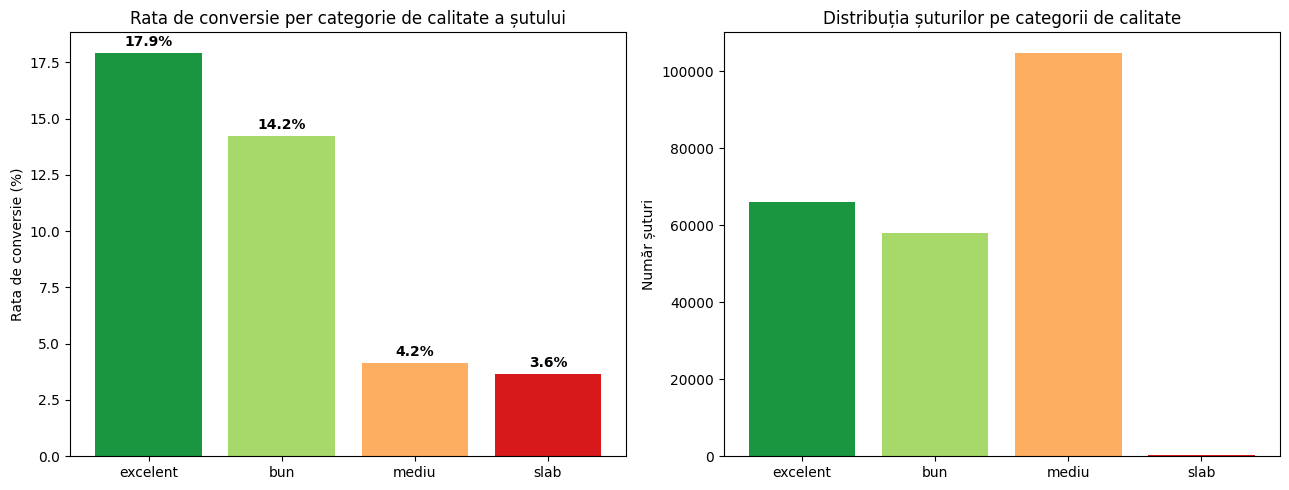

In [7]:
import matplotlib
import matplotlib.pyplot as plt

qa_pd = quality_analysis.toPandas()
# ROUND() din Spark SQL întoarce decimal.Decimal — îl convertim la float
# pentru aritmetica cu float din adnotările matplotlib (val + 0.3)
qa_pd['rata_conversie_pct'] = qa_pd['rata_conversie_pct'].astype(float)
order = ['excelent', 'bun', 'mediu', 'slab']
qa_pd = qa_pd.set_index('quality_label').reindex(order).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ['#1a9641', '#a6d96a', '#fdae61', '#d7191c']

axes[0].bar(qa_pd['quality_label'], qa_pd['rata_conversie_pct'], color=colors)
for i, (label, val) in enumerate(zip(qa_pd['quality_label'], qa_pd['rata_conversie_pct'])):
    axes[0].text(i, val + 0.3, f'{val:.1f}%', ha='center', fontweight='bold')
axes[0].set_ylabel('Rata de conversie (%)')
axes[0].set_title('Rata de conversie per categorie de calitate a șutului')

axes[1].bar(qa_pd['quality_label'], qa_pd['total_suturi'], color=colors)
axes[1].set_ylabel('Număr șuturi')
axes[1].set_title('Distribuția șuturilor pe categorii de calitate')

plt.tight_layout()
plt.savefig('plots/fig_shot_quality_udf.png', dpi=120, bbox_inches='tight')
plt.show()

## 5.2 Pandas UDF vectorizat (`@pandas_udf`) + benchmark

Rescriem aceeași logică de scor sub forma unui **Pandas UDF** (vectorizat) și o comparăm cu UDF-ul standard de mai sus.


In [8]:
# Aceeași logică de scor, dar VECTORIZATĂ ca Pandas UDF (procesează un batch întreg, nu un rând)
@pandas_udf(FloatType())
def shot_quality_score_vec(location: pd.Series, bodypart: pd.Series,
                           situation: pd.Series, fast_break: pd.Series) -> pd.Series:
    # Toate argumentele sosesc ca pandas.Series (un lot de rânduri), prin Apache Arrow
    loc = location.to_numpy()
    bp  = bodypart.to_numpy()
    sit = situation.to_numpy()
    fb  = fast_break.to_numpy()

    score = np.zeros(len(loc), dtype='float64')

    # Factor 1: locație (40%)
    central = np.isin(loc, [3, 5, 10, 12, 13, 14])
    good    = np.isin(loc, [4, 6, 9, 11])
    score += np.where(central, 0.40, np.where(good, 0.20, 0.05))

    # Factor 2: parte corp (25%) — doar dacă nu e null
    bp_ok = ~pd.isna(bp)
    score += np.where(bp_ok, np.where(np.isin(bp, [1, 2]), 0.25, 0.15), 0.0)

    # Factor 3: situație (20%) — doar dacă nu e null
    sit_ok = ~pd.isna(sit)
    score += np.where(sit_ok, np.where(sit == 1, 0.20, np.where(sit == 4, 0.15, 0.08)), 0.0)

    # Factor 4: contraatac rapid (15%)
    fb_ok = ~pd.isna(fb)
    score += np.where(fb_ok & (fb == 1), 0.15, 0.0)

    score = np.minimum(score, 1.0)
    # Locație null => scor 0.0 (identic cu comportamentul UDF-ului standard)
    score = np.where(~pd.isna(loc), score, 0.0)
    return pd.Series(score, dtype='float32')


print('Pandas UDF înregistrat: shot_quality_score_vec')

Pandas UDF înregistrat: shot_quality_score_vec


Diferența maximă UDF vs Pandas UDF (3000 rânduri): 0.000000
=> Rezultate identice.



UDF standard (row-at-a-time): 0.27s | scor mediu=0.6270
Pandas UDF (vectorizat)     : 0.21s | scor mediu=0.6270
Speedup Pandas UDF: 1.28x


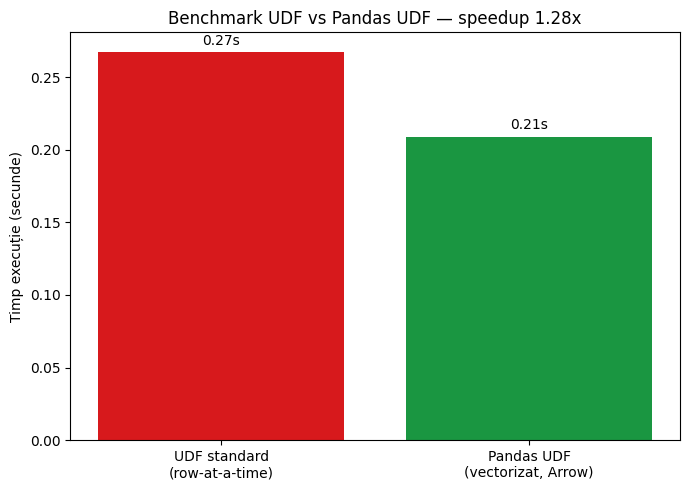

In [9]:
import time
from pyspark.sql.functions import avg as spark_avg

args = (col('location'), col('bodypart'), col('situation'), col('fast_break'))

# 1) Verificare corectitudine: ambele variante trebuie să dea EXACT același scor
check = (shots_df.limit(3000)
         .withColumn('q_udf',  shot_quality_score(*args))
         .withColumn('q_pudf', shot_quality_score_vec(*args))
         .select('q_udf', 'q_pudf').toPandas())
max_diff = (check['q_udf'] - check['q_pudf']).abs().max()
print(f'Diferența maximă UDF vs Pandas UDF (3000 rânduri): {max_diff:.6f}')
print('=> Rezultate identice.' if max_diff < 1e-5 else '=> ATENȚIE: diferențe între variante!')

# 2) Warmup pentru ambele căi (pornirea workerilor Python + codegen) — benchmark corect
shots_df.withColumn('q', shot_quality_score(*args)).agg(spark_avg('q')).collect()
shots_df.withColumn('q', shot_quality_score_vec(*args)).agg(spark_avg('q')).collect()

def timp(expr_udf):
    t0 = time.time()
    val = shots_df.withColumn('q', expr_udf).agg(spark_avg('q')).collect()[0][0]
    return time.time() - t0, val

t_udf,  v_udf  = timp(shot_quality_score(*args))
t_pudf, v_pudf = timp(shot_quality_score_vec(*args))

print(f'\nUDF standard (row-at-a-time): {t_udf:.2f}s | scor mediu={v_udf:.4f}')
print(f'Pandas UDF (vectorizat)     : {t_pudf:.2f}s | scor mediu={v_pudf:.4f}')
speedup = t_udf / t_pudf if t_pudf > 0 else float('nan')
print(f'Speedup Pandas UDF: {speedup:.2f}x')

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(['UDF standard\n(row-at-a-time)', 'Pandas UDF\n(vectorizat, Arrow)'],
              [t_udf, t_pudf], color=['#d7191c', '#1a9641'])
ax.bar_label(bars, fmt='%.2fs', padding=3)
ax.set_ylabel('Timp execuție (secunde)')
ax.set_title(f'Benchmark UDF vs Pandas UDF — speedup {speedup:.2f}x')
plt.tight_layout()
plt.savefig('plots/fig_udf_benchmark.png', dpi=120, bbox_inches='tight')
plt.show()

## 5.3 Optimizarea Hiperparametrilor — CrossValidator

### Motivație

Parametrii impliciți ai unui model sunt rareori optimi pentru un dataset specific. `CrossValidator` cu `ParamGridBuilder` caută sistematic cea mai bună combinație de hiperparametri prin **k-fold cross-validation**, evitând overfitting-ul față de setul de test.

### Parametrii explorați pentru Random Forest

- `numTrees` — numărul de arbori din pădure
- `maxDepth` — adâncimea maximă a fiecărui arbore
- `minInstancesPerNode` — numărul minim de exemple dintr-un nod frunză


In [10]:
# Adăugăm shot_quality ca feature suplimentar (beneficiind de UDF)
feature_cols = ['location', 'bodypart', 'situation', 'assist_method',
                'fast_break', 'shot_place', 'side', 'time', 'shot_quality']

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol='features',
    handleInvalid='skip'
)

rf = RandomForestClassifier(
    labelCol='is_goal',
    featuresCol='features',
    seed=42
)

pipeline = Pipeline(stages=[assembler, rf])

# Grid de hiperparametri
param_grid = ParamGridBuilder() \
    .addGrid(rf.numTrees,            [50, 100]) \
    .addGrid(rf.maxDepth,            [5, 10]) \
    .addGrid(rf.minInstancesPerNode, [1, 5]) \
    .build()

evaluator = BinaryClassificationEvaluator(
    labelCol='is_goal',
    metricName='areaUnderROC'
)

cv = CrossValidator(
    estimator=pipeline,
    estimatorParamMaps=param_grid,
    evaluator=evaluator,
    numFolds=3,
    parallelism=2,
    seed=42
)

n_combinations = len(param_grid)
print(f'Grila de parametri: {n_combinations} combinații × 3 folds = {n_combinations*3} antrenări')

Grila de parametri: 8 combinații × 3 folds = 24 antrenări


### Rularea CrossValidator — 24 de antrenări

Grid-ul are 8 combinații (2×2×2), fiecare evaluată cu 3-fold cross-validation → 24 de modele antrenate. De aceea folosim un sample de 30% din date: scopul e *compararea* hiperparametrilor, nu modelul final de producție, iar pe sample comparația rămâne validă.


In [11]:
# Folosim un sample pentru a reduce timpul de rulare la ~10 min
sample_df = shots_with_quality.sample(fraction=0.3, seed=42)
train_df, test_df = sample_df.randomSplit([0.8, 0.2], seed=42)

print(f'Train: {train_df.count():,} | Test: {test_df.count():,}')
print('Rulare CrossValidator (poate dura câteva minute)...')

cv_model = cv.fit(train_df)
print('CrossValidator finalizat.')

Train: 55,117 | Test: 13,566
Rulare CrossValidator (poate dura câteva minute)...


CrossValidator finalizat.


### Extragerea celui mai bun model și analiza grid-ului

`cv_model.bestModel` e pipeline-ul reantrenat automat pe *tot* train-ul cu combinația câștigătoare. Afișăm hiperparametrii câștigători, evaluăm pe test (date nevăzute de CV) și listăm AUC-ul mediu per combinație din `avgMetrics` — ca să vedem nu doar cine a câștigat, ci și cât de sensibil e modelul la fiecare hiperparametru.


In [12]:
# Cel mai bun model
best_rf = cv_model.bestModel.stages[-1]

print('=== Cel mai bun model găsit ===')
print(f'  numTrees            : {best_rf.getNumTrees}')
print(f'  maxDepth            : {best_rf.getOrDefault("maxDepth")}')
print(f'  minInstancesPerNode : {best_rf.getOrDefault("minInstancesPerNode")}')

best_preds = cv_model.transform(test_df)
best_auc   = evaluator.evaluate(best_preds)

mc_eval = MulticlassClassificationEvaluator(labelCol='is_goal', metricName='f1')
best_f1 = mc_eval.evaluate(best_preds)

print(f'\n  AUC-ROC pe test : {best_auc:.4f}')
print(f'  F1-Score pe test: {best_f1:.4f}')

=== Cel mai bun model găsit ===
  numTrees            : 50
  maxDepth            : 10
  minInstancesPerNode : 1



  AUC-ROC pe test : 0.9576
  F1-Score pe test: 0.9254


In [13]:
# Compararea scorurilor AUC pentru toate combinațiile din grid
avg_metrics = cv_model.avgMetrics

results = []
for params, score in zip(param_grid, avg_metrics):
    row = {p.name: v for p, v in params.items()}
    row['auc_cv'] = round(score, 4)
    results.append(row)

results_df = pd.DataFrame(results).sort_values('auc_cv', ascending=False)
print('Toate combinațiile testate (ordonate după AUC-ROC):')
print(results_df.to_string(index=False))

Toate combinațiile testate (ordonate după AUC-ROC):
 numTrees  maxDepth  minInstancesPerNode  auc_cv
       50        10                    1  0.9557
      100        10                    1  0.9544
      100        10                    5  0.9541
       50        10                    5  0.9536
       50         5                    5  0.9129
       50         5                    1  0.9123
      100         5                    1  0.9059
      100         5                    5  0.9043


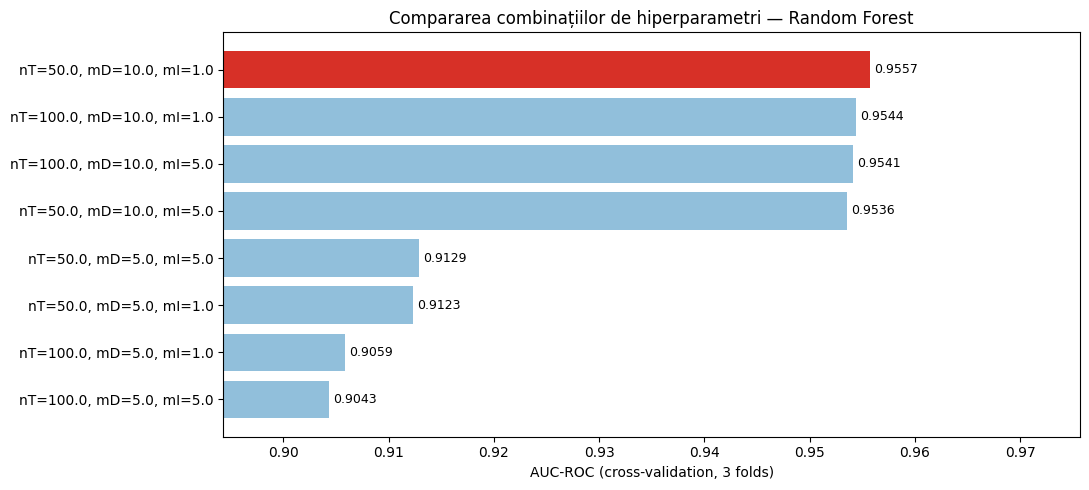

Sesiune Spark oprită.


In [14]:
fig, ax = plt.subplots(figsize=(11, 5))
labels = [f'nT={r["numTrees"]}, mD={r["maxDepth"]}, mI={r["minInstancesPerNode"]}'
          for _, r in results_df.iterrows()]
colors_cv = ['#d73027' if i == 0 else '#91bfdb' for i in range(len(results_df))]

bars = ax.barh(labels[::-1], results_df['auc_cv'][::-1], color=colors_cv[::-1])
ax.bar_label(bars, fmt='{:.4f}', padding=3, fontsize=9)
ax.set_xlabel('AUC-ROC (cross-validation, 3 folds)')
ax.set_title('Compararea combinațiilor de hiperparametri — Random Forest')
ax.set_xlim(results_df['auc_cv'].min() - 0.01, results_df['auc_cv'].max() + 0.02)

plt.tight_layout()
plt.savefig('plots/fig_hyperparameter_tuning.png', dpi=120, bbox_inches='tight')
plt.show()

spark.stop()
print('Sesiune Spark oprită.')